## Load Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


### Observation

The required Python libraries were imported for data analysis,
visualization, preprocessing, machine learning model training,
and model evaluation.

## Step 1: Load Libraries & Dataset

In [10]:
df=pd.read_csv("insurance (1).csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Step 2: EDA & Check Duplicates

In [13]:
# Check missing values and data types
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


Text(0.5, 1.0, 'Original Charges Distribution')

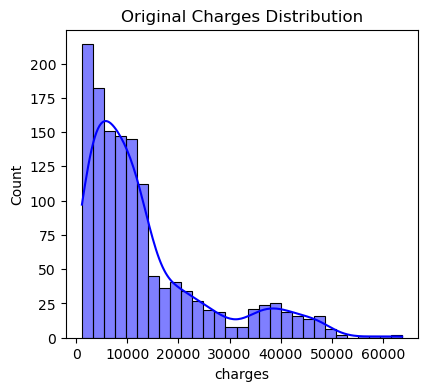

In [15]:
# Plot distribution of target variable (charges)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Original Charges Distribution')

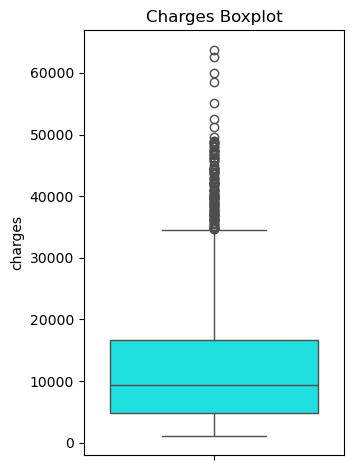

In [16]:
plt.subplot(1, 2, 2)
sns.boxplot(y=df['charges'], color='cyan')
plt.title('Charges Boxplot')
plt.tight_layout()
plt.show()

## Step 3: Data Cleaning (Drop 1 Duplicate & Target Log Transform)

In [17]:
# Remove the 1 duplicate record
df.drop_duplicates(inplace=True)
print("Shape after removing duplicate:", df.shape)

Shape after removing duplicate: (1337, 7)


In [18]:
# Apply Log Transformation to normalize right-skewed charges
df['charges_log'] = np.log1p(df['charges'])

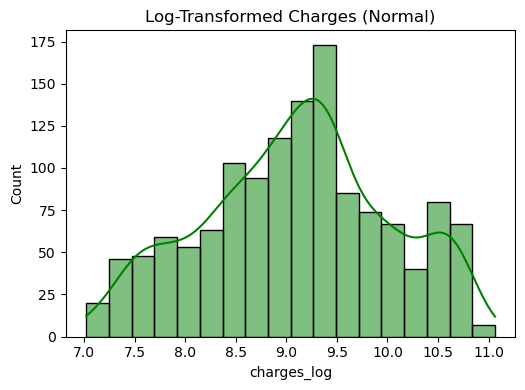

In [21]:
#afetr log transformed
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 2)
sns.histplot(df['charges_log'], kde=True, color='green')
plt.title('Log-Transformed Charges (Normal)')
plt.tight_layout()
plt.show()

## Step 4: Categorical Encoding & Feature Setup


In [24]:
# Separate features and log target
X = df.drop(columns=['charges', 'charges_log'])
y = df['charges_log']

In [25]:
# Define numerical and categorical features
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

## Step 5: Train-Test Split

In [26]:
# Split dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

Training Samples: 1069, Testing Samples: 268


## Step 6: Preprocessing & Feature Scaling

In [29]:
# Build Preprocessor Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Fit preprocessor on X_train and transform X_test
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Step 7: Train Regression Models

In [33]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Support Vector Regressor': SVR(C=1.0, epsilon=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

## Step 8: Model Evaluation & Metrics

In [41]:
results = []
usd_to_inr = 83.0  # Conversion rate multiplier

for name, model in models.items():
    # Predict on test set
    preds_log = model.predict(X_test_scaled)
    
    # Convert predictions & actuals to INR
    preds_actual_inr = np.expm1(preds_log) * usd_to_inr
    y_test_actual_inr = np.expm1(y_test) * usd_to_inr
    
    # Calculate performance metrics
    r2 = r2_score(y_test_actual_inr, preds_actual_inr)
    mae = mean_absolute_error(y_test_actual_inr, preds_actual_inr)
    rmse = np.sqrt(mean_squared_error(y_test_actual_inr, preds_actual_inr))
    
    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE (₹)': f"₹{mae:,.2f}",
        'RMSE (₹)': f"₹{rmse:,.2f}"
    })

# Format metric table
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,R2 Score,MAE (₹),RMSE (₹)
0,Gradient Boosting,0.8958,"₹176,381.84","₹363,121.99"
1,Random Forest,0.8944,"₹174,615.01","₹365,620.10"
2,Support Vector Regressor,0.8414,"₹209,026.48","₹448,111.48"
3,Decision Tree,0.7758,"₹250,469.12","₹532,769.98"
4,Lasso Regression,0.7275,"₹317,611.28","₹587,280.14"
5,Ridge Regression,0.7207,"₹311,596.74","₹594,595.94"
6,Linear Regression,0.7181,"₹311,741.74","₹597,353.71"
7,KNN Regressor,0.5348,"₹393,065.12","₹767,391.80"


## Step 9: Model Serialization & Pipeline Save

In [36]:
import joblib
from sklearn.pipeline import Pipeline
# Select top-performing model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Top Performing Model: {best_model_name}")

# Export full pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_model)
])

joblib.dump(final_pipeline, 'insurance_model.pkl')
print("Model pipeline saved as 'insurance_model.pkl'")


Top Performing Model: Gradient Boosting
Model pipeline saved as 'insurance_model.pkl'


In [42]:
import joblib
import pandas as pd
import numpy as np

pipeline = joblib.load('insurance_model.pkl')

# 1. Profile with SMOKER = YES
patient_smoker = pd.DataFrame([{
    'age': 35, 'sex': 'male', 'bmi': 28.5, 
    'children': 2, 'smoker': 'yes', 'region': 'southeast'
}])

# 2. Profile with SMOKER = NO
patient_non_smoker = pd.DataFrame([{
    'age': 35, 'sex': 'male', 'bmi': 28.5, 
    'children': 2, 'smoker': 'no', 'region': 'southeast'
}])

# Predict and convert to INR (83.0 rate)
charge_smoker = np.expm1(pipeline.predict(patient_smoker))[0] * 83.0
charge_non_smoker = np.expm1(pipeline.predict(patient_non_smoker))[0] * 83.0

print(f"Smoker Charge:     ₹{charge_smoker:,.2f}")
print(f"Non-Smoker Charge: ₹{charge_non_smoker:,.2f}")

Smoker Charge:     ₹1,645,066.67
Non-Smoker Charge: ₹496,296.29
